In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

In [6]:
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
data = pd.read_csv(url)
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


The data is brought from an external site called github

Since the traget variable(charges) is numerical this is regression

Random Forest Regression is chosen because it can handle the non - linear relationship btw bmi and charges, smoker and cahrges, etc.(since the when bmi inc there may or may not be a inc in charges). so , random forest regreeor can understand the complex relationship.

In [7]:
print(data.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [8]:
print(data.duplicated().sum())

1


In [12]:
data[data.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [14]:
data = data.drop_duplicates()

In [15]:
data.duplicated().sum()

np.int64(0)

In [18]:
data = pd.get_dummies(data, drop_first = True) # done using One Hot Encoding One Hot Encoding is done using get_dummies

In [ ]:
data # so here sex has 2 category male and female, so here drop_first = true is given so female(comes first in dataset) does not create as an additional column name only male is created as new column(like sex_male), 
# so it becomes se_male - True (if male), false(if female), similarrly for resion, smoker.

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,True,False,True,False,False
1334,18,31.920,0,2205.98080,False,False,False,False,False
1335,18,36.850,0,1629.83350,False,False,False,True,False
1336,21,25.800,0,2007.94500,False,False,False,False,True


In [20]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1337 non-null   int64  
 1   bmi               1337 non-null   float64
 2   children          1337 non-null   int64  
 3   charges           1337 non-null   float64
 4   sex_male          1337 non-null   bool   
 5   smoker_yes        1337 non-null   bool   
 6   region_northwest  1337 non-null   bool   
 7   region_southeast  1337 non-null   bool   
 8   region_southwest  1337 non-null   bool   
dtypes: bool(5), float64(2), int64(2)
memory usage: 58.8 KB
None


In [21]:
x = data.drop('charges', axis = 1)
y = data['charges']

In [22]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [25]:
rf = RandomForestRegressor(random_state = 42)
rf.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [26]:
y_pred = rf.predict(x_test)

In [29]:
print('mean absolute error', mean_absolute_error(y_test, y_pred))
print('mean squaredd error', mean_squared_error(y_test, y_pred))
print('r2 score', r2_score(y_test, y_pred))

mean absolute error 2637.9945481492537
mean squaredd error 22113000.538090803
r2 score 0.8796611113027272


MAE = The models prediction is wrong by ₹2,638.
Lower mAE better model
MSE - models error are squared and then averaged
lowe MSE  better model
R2 Score - 88% , the model explains approximately 88% of the variation in insurance charges. A higher R² indicates better model performance. 

EG:
Person A
Age = 25
BMI = 25
Smoker = No
Children = 0

model predicts:

₹3,000

Actual charge:

₹3,200

Pretty close. 👍

👨 Person B
Age = 50
BMI = 35
Smoker = Yes
Children = 2

Your model predicts:

₹25,000

Actual charge:

₹27,000

Again, fairly close.

Your model looks at things like age, BMI, smoker, children, etc. and uses them to explain why one person's insurance charge is different from another person's.

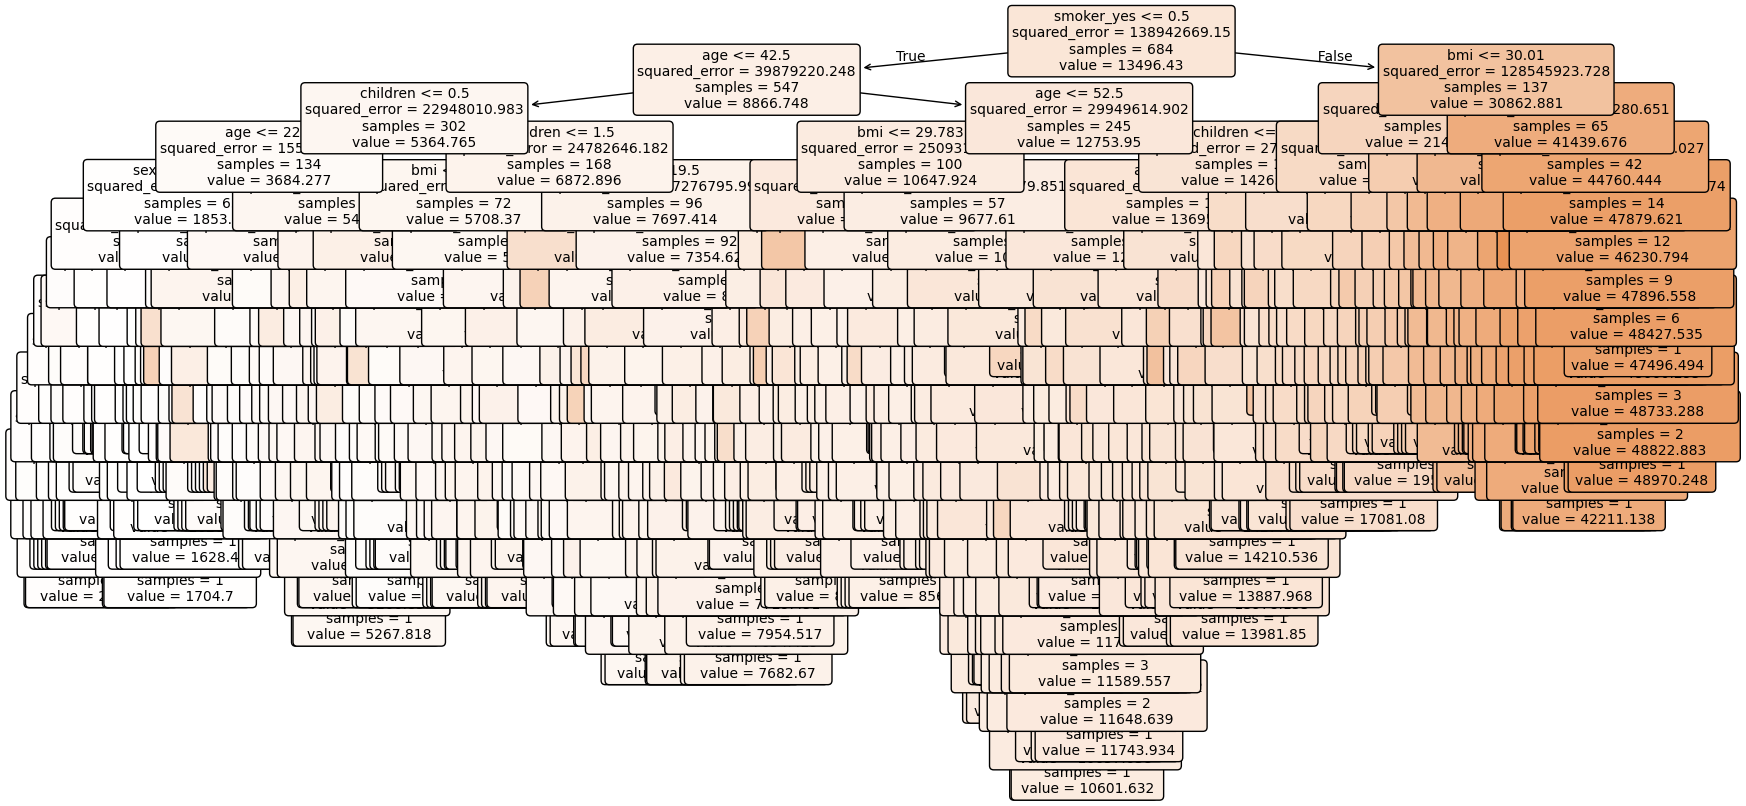

In [33]:
# Visualization of 1 tree
from sklearn.tree import export_graphviz
from sklearn import tree
import matplotlib.pyplot as plt
plt.figure(figsize =(20,10))
tree.plot_tree(rf.estimators_[0], feature_names = x.columns, filled = True, rounded = True, fontsize = 10)
plt.show()

In [34]:
new_person = [[ 19,27.9,0,1,1,0,0,1]]
prediction = rf.predict(new_person)
print(prediction[0])

17280.432200900013


c:\Users\POOJA\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [38]:
# comapring actual value with predicted value
y_pred = rf.predict(x_test)
comparison = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
print(comparison)

          Actual     Predicted
0     8688.85885   9293.312624
1     5708.86700   8884.977884
2    11436.73815  11867.274350
3    38746.35510  42030.155849
4     4463.20510   6638.508807
..           ...           ...
263  13831.11520  14326.345954
264  13887.20400  14890.013923
265   3925.75820   9216.500922
266  47403.88000  47981.428923
267   8534.67180  13769.049036

[268 rows x 2 columns]
